# 03 — Modelo D+1 (previsão de volume para o dia seguinte)

Volume de incidentes elegíveis a KPI no dia seguinte.

O protocolo é o mesmo para todos os modelos de previsão:

1. cada família de algoritmo treina cada configuração da sua grade **só com o treino**;
2. o vencedor é escolhido **na validação**;
3. o vencedor é reajustado em treino + validação;
4. o **teste** é lido uma única vez, no fim, e é o número publicado na plataforma;
5. o mesmo modelo ainda passa por um **walk-forward** de 12 origens semanais.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings('ignore')
RAIZ = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

from ml.src import config, dataset, explain, features, metrics, models_zoo, registry, selecao, splits, train
print('Banco:', config.BANCO, '| existe:', config.BANCO.exists())

Banco: C:\Users\Usuario\Downloads\CP\sentinel_ops\db.sqlite3 | existe: True


In [2]:
base = train.preparar_base(verbose=True)

Regime operacional detectado a partir de 2025-01-13 (120,670 incidentes, 55 entidades).
Matriz de features: 122,507 linhas × 85 features.


In [3]:
horizontes = [1]
matriz = base['matriz'][base['matriz']['horizonte'].isin(horizontes)].reset_index(drop=True)
treino, validacao, teste = splits.dividir(matriz)

colunas = features.colunas_de_features(matriz)
X = matriz[colunas].astype(float).fillna(0.0).replace([np.inf, -np.inf], 0.0)
if len(horizontes) == 1:
    X = X.drop(columns=['horizonte'])
y = matriz['alvo'].astype(float)

pd.DataFrame(splits.descricao(matriz)).T

,linhas,inicio,fim
treino,14586,2025-02-12,2025-11-05
validacao,1540,2025-11-06,2025-12-03
teste,1540,2025-12-04,2025-12-31


## Treino: competição, seleção e registro

`train.treinar_volume` executa o protocolo inteiro — treina cada candidato só com o treino,
escolhe pela validação, reajusta o vencedor em treino + validação, mede uma vez no teste e grava
o artefato em `ml/models/`. É a **mesma função** que `manage.py treinar_modelos` chama, então o
modelo deste notebook é o modelo que a plataforma serve.

A célula abaixo é a parte cara (alguns minutos): ela treina todas as famílias de algoritmo. A
tabela de comparação que aparece em seguida sai do cartão gravado por esta execução — não é uma
segunda competição, é o registro da que acabou de acontecer.

In [4]:
cartao = train.treinar_volume(
    base, 'model_d1', '03',
    'Volume de incidentes elegíveis a KPI no dia seguinte.',
    horizontes=[1], ordem=1,
    notebook='ml/notebooks/03_model_d1.ipynb',
)
print('Artefato gravado  :', cartao['nome'], '->',
      registry.caminho_artefato(cartao['nome']).name)
print('Algoritmo vencedor:', cartao['algoritmo'])
print('Hiperparâmetros   :', cartao['hiperparametros'])
pd.Series(cartao['metricas']['teste']).to_frame('teste')

Artefato gravado  : model_d1 -> model_d1.pkl
Algoritmo vencedor: XGBRegressor
Hiperparâmetros   : {'n_estimators': 900, 'learning_rate': 0.03, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.6, 'reg_lambda': 3.0}


,teste
mae,1.8603
rmse,3.9009
mape,74.3625
r2,0.8083
vies,-0.9336
n,1540.0000
mae_baseline,2.2435
mase,0.8292
ganho_vs_baseline,17.0793


### Comparação entre algoritmos (medida na validação)

As duas baselines entram como estimadores de verdade, na mesma partição e na mesma métrica — é o
que permite afirmar que o ML acrescenta algo em vez de supor.

,candidato,tipo,algoritmo,vencedor,mae,rmse,mase,r2
4,XGBoost,arvore,XGBRegressor,True,1.8735,3.7791,0.7672,0.8795
5,LightGBM,arvore,LGBMRegressor,False,1.8830,3.9274,0.7710,0.8698
3,Random Forest,arvore,RandomForestRegressor,False,1.9040,3.8011,0.7796,0.8781
2,Ridge,linear,Ridge,False,1.9563,3.9614,0.8010,0.8676
1,Baseline média 7d,baseline,PreverColuna,False,2.3405,4.9516,0.9584,0.7931
0,Baseline sazonal,baseline,PreverColuna,False,2.4422,5.1612,1.0000,0.7752


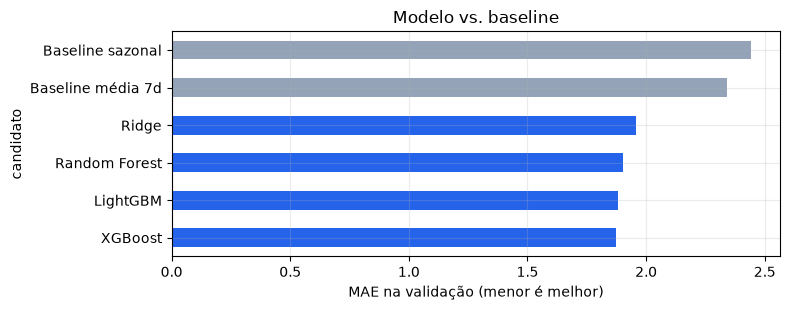

In [5]:
comparacao = pd.DataFrame([
    {'candidato': l['candidato'], 'tipo': l['tipo'], 'algoritmo': l['algoritmo'],
     'vencedor': l.get('vencedor', False), **l['metricas']}
    for l in cartao['comparacao']
]).sort_values('mae')
display(comparacao)

resumo = comparacao.set_index('candidato')['mae'].sort_values()
fig, eixo = plt.subplots(figsize=(8, 3.2))
cores = ['#94a3b8' if 'Baseline' in nome else '#2563eb' for nome in resumo.index]
resumo.plot(kind='barh', ax=eixo, color=cores)
eixo.set_xlabel('MAE na validação (menor é melhor)')
eixo.set_title('Modelo vs. baseline')
plt.tight_layout(); plt.show()

In [6]:
grade = pd.DataFrame([
    {'candidato': l['candidato'], 'hiperparametros': str(l['hiperparametros']),
     'segundos': l['segundos_treino'], 'mae': l['validacao']['mae'],
     'vencedor': l.get('vencedor', False)}
    for l in cartao['comparacao_completa']
])
print('Todas as configurações testadas, uma linha por ponto da grade:')
grade.sort_values('mae')

Todas as configurações testadas, uma linha por ponto da grade:


,candidato,hiperparametros,segundos,mae,vencedor
10,XGBoost,"{'n_estimators': 900, 'learning_rate': 0.03, '...",3.59,1.8735,True
9,XGBoost,"{'n_estimators': 400, 'learning_rate': 0.08, '...",1.04,1.8818,False
12,LightGBM,"{'n_estimators': 400, 'learning_rate': 0.08, '...",0.43,1.8830,False
8,XGBoost,"{'n_estimators': 600, 'learning_rate': 0.05, '...",1.99,1.8884,False
5,Random Forest,"{'n_estimators': 300, 'min_samples_leaf': 5, '...",3.91,1.9040,False
6,Random Forest,"{'n_estimators': 300, 'min_samples_leaf': 5, '...",4.97,1.9102,False
7,Random Forest,"{'n_estimators': 300, 'min_samples_leaf': 10, ...",7.30,1.9289,False
11,LightGBM,"{'n_estimators': 600, 'learning_rate': 0.05, '...",1.21,1.9478,False
4,Ridge,{'modelo__alpha': 100.0},0.03,1.9563,False
3,Ridge,{'modelo__alpha': 10.0},0.03,2.0303,False


In [7]:
print('MAE por tipo de entidade (o agregado mistura escalas muito diferentes):')
display(pd.DataFrame(cartao['metricas']['teste_por_dimensao']).T[
    ['mae', 'mae_baseline', 'ganho_vs_baseline', 'mape', 'r2', 'n']
])
if cartao['metricas'].get('teste_por_horizonte'):
    print('\nMAE por horizonte:')
    display(pd.DataFrame(cartao['metricas']['teste_por_horizonte']).T[['mae', 'mae_baseline', 'rmse', 'r2']])

MAE por tipo de entidade (o agregado mistura escalas muito diferentes):


,mae,mae_baseline,ganho_vs_baseline,mape,r2,n
categoria,1.6743,2.0387,17.8754,78.2002,0.4457,336.0
equipe,1.8577,2.2321,16.7731,76.4764,0.7550,336.0
global,13.6797,17.1429,20.2018,59.7268,0.2996,28.0
item,0.6594,0.6875,4.0936,48.5596,0.2359,224.0
prioridade,7.4337,9.3929,20.8581,102.9627,0.6103,56.0
produto,1.3056,1.5357,14.9834,72.4131,0.6844,560.0


## Walk-forward — 12 origens semanais

Uma partição única mede um recorte do calendário. Aqui o modelo é retreinado a cada semana e
avaliado nos 7 dias seguintes, repetidamente.

{'janelas': 12, 'mae': 1.813, 'rmse': 3.448, 'mae_baseline': 2.308, 'mase': 0.792, 'dispersao_mae': 0.153, 'vitorias_sobre_baseline': 12}


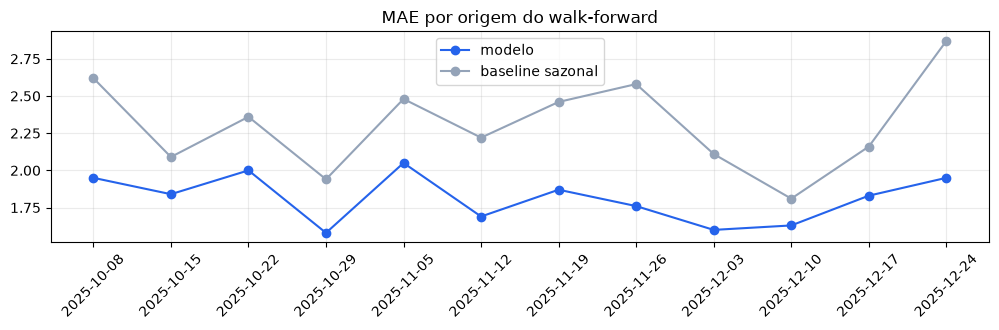

,origem,mae,mae_baseline,n
0,2025-10-08,1.95,2.62,385
1,2025-10-15,1.84,2.09,385
2,2025-10-22,2.00,2.36,385
3,2025-10-29,1.58,1.94,385
4,2025-11-05,2.05,2.48,385
5,2025-11-12,1.69,2.22,385
6,2025-11-19,1.87,2.46,385
7,2025-11-26,1.76,2.58,385
8,2025-12-03,1.60,2.11,385
9,2025-12-10,1.63,1.81,385


In [8]:
caminho = cartao['metricas']['walk_forward']
janelas = pd.DataFrame(caminho['por_origem'])
print({k: v for k, v in caminho.items() if k != 'por_origem'})

fig, eixo = plt.subplots(figsize=(10, 3.4))
eixo.plot(janelas['origem'], janelas['mae'], marker='o', label='modelo', color='#2563eb')
eixo.plot(janelas['origem'], janelas['mae_baseline'], marker='o', label='baseline sazonal', color='#94a3b8')
eixo.set_title('MAE por origem do walk-forward'); eixo.legend()
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
janelas

## Explicabilidade

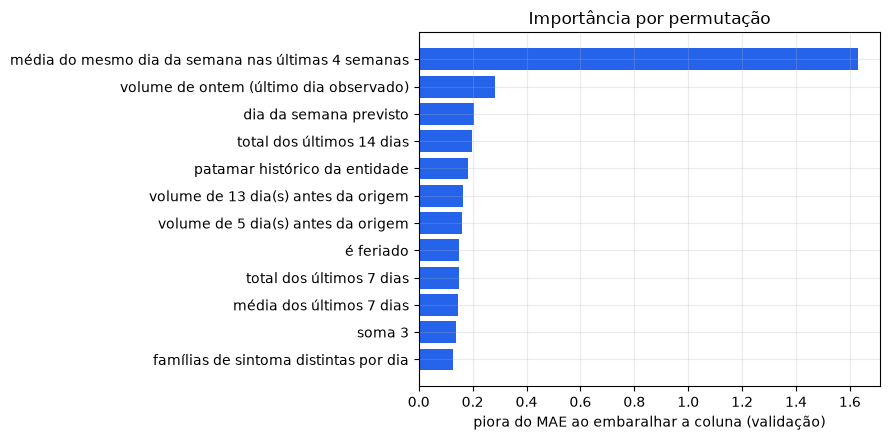

,feature,descricao,queda_metrica,desvio
0,media_mesmo_dow_4,média do mesmo dia da semana nas últimas 4 sem...,1.63023,0.01524
1,lag_0,volume de ontem (último dia observado),0.28268,0.00139
2,dow,dia da semana previsto,0.20354,0.01206
3,soma_14,total dos últimos 14 dias,0.19681,0.00565
4,media_expandida,patamar histórico da entidade,0.18363,0.00743
5,lag_13,volume de 13 dia(s) antes da origem,0.16495,0.00511
6,lag_5,volume de 5 dia(s) antes da origem,0.16080,0.00666
7,feriado,é feriado,0.15061,0.02400
8,soma_7,total dos últimos 7 dias,0.14961,0.00428
9,media_7,média dos últimos 7 dias,0.14692,0.00543


In [9]:
permutacao = pd.DataFrame(cartao['importancia_permutacao'])
fig, eixo = plt.subplots(figsize=(9, 4.5))
recorte = permutacao.head(12).iloc[::-1]
eixo.barh(recorte['descricao'], recorte['queda_metrica'], color='#2563eb')
eixo.set_xlabel('piora do MAE ao embaralhar a coluna (validação)')
eixo.set_title('Importância por permutação')
plt.tight_layout(); plt.show()
permutacao.head(12)

In [10]:
artefato = registry.carregar(cartao['nome'])
# Sempre pelas colunas do artefato: é o contrato entre treino e inferência, e qualquer
# reordenação silenciosa aqui produziria uma explicação bonita e errada.
X_teste = X.loc[teste, artefato['colunas']]
contribuicoes = explain.contribuicoes_shap(
    artefato['explicador'], X_teste.tail(1), artefato['colunas'], limite=10,
)
print('Contribuições SHAP de uma previsão individual')
print('valor base (previsão média do modelo):', round(float(artefato['explicador'].expected_value), 2))
pd.DataFrame(contribuicoes)

Contribuições SHAP de uma previsão individual
valor base (previsão média do modelo): 6.42


,feature,descricao,contribuicao,valor,sentido
0,media_mesmo_dow_4,média do mesmo dia da semana nas últimas 4 sem...,-2.143,0.000,reduz
1,soma_14,total dos últimos 14 dias,-0.401,4.000,reduz
2,lag_0,volume de ontem (último dia observado),-0.322,0.000,reduz
3,media_expandida,patamar histórico da entidade,-0.297,0.473,reduz
4,soma_7,total dos últimos 7 dias,-0.288,0.000,reduz
5,lag_13,volume de 13 dia(s) antes da origem,-0.283,0.000,reduz
6,vespera_feriado,véspera de feriado,-0.243,1.000,reduz
7,share_global_28,peso da entidade no volume total,-0.231,0.006,reduz
8,media_7,média dos últimos 7 dias,-0.226,0.000,reduz
9,dow,dia da semana previsto,0.196,2.000,aumenta


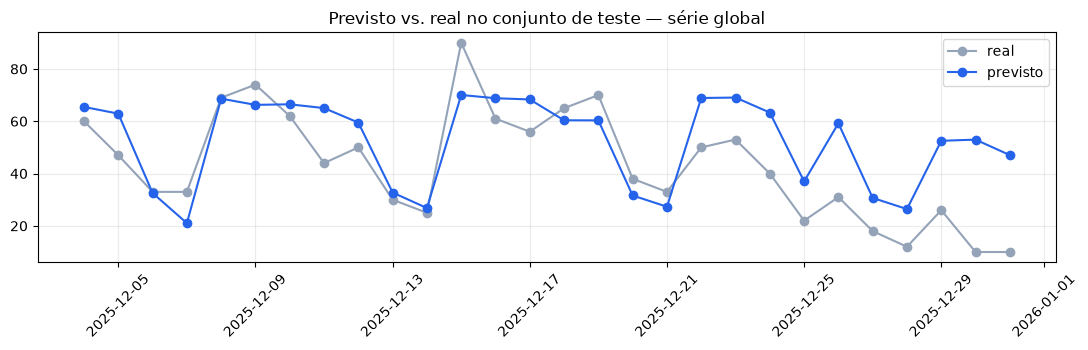

In [11]:
previsto = np.clip(artefato['modelo'].predict(X_teste), 0, None)
real = y[teste].to_numpy()
global_mask = (matriz.loc[teste, 'dimensao'] == 'global').to_numpy()

fig, eixo = plt.subplots(figsize=(11, 3.6))
datas = matriz.loc[teste, 'data_alvo'].to_numpy()[global_mask]
eixo.plot(datas, real[global_mask], marker='o', label='real', color='#94a3b8')
eixo.plot(datas, previsto[global_mask], marker='o', label='previsto', color='#2563eb')
eixo.set_title('Previsto vs. real no conjunto de teste — série global')
eixo.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()